# ProspectML — Final Analysis & Conclusions

This notebook uses the finalized ProspectML model developed in Notebook 4 to investigate what Minor League performance can tell us about future MLB hitting ability.

Rather than further optimizing the model, the goal of this notebook is to interpret the model and answer several baseball questions:

1. What aspects of MLB hitting are easiest to predict?
2. What Minor League characteristics does ProspectML rely on most?
3. Does performance across different Minor League levels provide different amounts of predictive information?
4. Where does ProspectML succeed and fail?
5. What can these results tell us about projecting Minor League hitters to MLB performance?

In [9]:
import pandas as pd
import numpy as np
import joblib

# Load finalized models and information
component_models = joblib.load(
    "prospectml_final_component_models.pkl"
)

final_features = joblib.load(
    "prospectml_final_features.pkl"
)

component_train_stats = joblib.load(
    "prospectml_component_train_stats.pkl"
)

# Load finalized dataset
prospectml_model = pd.read_csv(
    "C:\\Users\\ncodi\\OneDrive\\Documents\\ProspectML\\Data\\prospectml_final_analysis_data.csv"
)

print("Final ProspectML model and dataset loaded.")

Final ProspectML model and dataset loaded.


In [10]:
print(f"Players: {len(prospectml_model):,}")
print(f"Final model features: {len(final_features)}")

missing_features = [
    feature
    for feature in final_features
    if feature not in prospectml_model.columns
]

print(f"Missing features: {len(missing_features)}")

if missing_features:
    print(missing_features)
else:
    print("All model features are present.")

Players: 936
Final model features: 33
Missing features: 0
All model features are present.


## Generating Final MLB Component Predictions

The finalized ProspectML model consists of four Extra Trees models that independently predict future MLB OBP, ISO, wOBA, and wRC+.

These predictions will be used to construct a final predicted Hitter Ability Score for each player in the dataset.

No additional model training or tuning is performed in this notebook. The purpose of Notebook 5 is to analyze and interpret the finalized model.

In [14]:
component_targets = [
    "MLB_OBP",
    "MLB_ISO",
    "MLB_wOBA",
    "MLB_wRC_plus"
]

HAS_WEIGHTS = {
    "MLB_OBP": 0.15,
    "MLB_ISO": 0.15,
    "MLB_wOBA": 0.35,
    "MLB_wRC_plus": 0.35
}

In [13]:
component_predictions_final = {}

for target in component_targets:

    model = component_models[target]

    component_predictions_final[target] = model.predict(
        prospectml_model[final_features]
    )

    print(
        f"{target}: "
        f"min={component_predictions_final[target].min():.4f}, "
        f"max={component_predictions_final[target].max():.4f}"
    )

MLB_OBP: min=0.2707, max=0.3710
MLB_ISO: min=0.0665, max=0.2226
MLB_wOBA: min=0.2678, max=0.3570
MLB_wRC_plus: min=62.1352, max=122.5760


In [15]:
predicted_z_final = {}

for target in component_targets:

    mean = component_train_stats[target]["mean"]
    std = component_train_stats[target]["std"]

    predicted_z_final[target] = (
        component_predictions_final[target] - mean
    ) / std

In [16]:
prospectml_model["Predicted_HAS"] = (
    HAS_WEIGHTS["MLB_OBP"] * predicted_z_final["MLB_OBP"] +
    HAS_WEIGHTS["MLB_ISO"] * predicted_z_final["MLB_ISO"] +
    HAS_WEIGHTS["MLB_wOBA"] * predicted_z_final["MLB_wOBA"] +
    HAS_WEIGHTS["MLB_wRC_plus"] * predicted_z_final["MLB_wRC_plus"]
)

In [17]:
print(prospectml_model["Predicted_HAS"].describe())

count    936.000000
mean      -0.009993
std        0.573115
min       -1.440096
25%       -0.426530
50%       -0.042330
75%        0.392800
max        1.762978
Name: Predicted_HAS, dtype: float64


## Final HAS Predictions

The finalized ProspectML models were used to generate predicted Hitter Ability Scores for all players in the final dataset.

Prediction error is calculated as the difference between predicted HAS and the actual MLB-based HAS. These predictions will be used throughout this notebook to evaluate the model's strengths, identify where it succeeds and fails, and investigate broader questions about the translation of Minor League hitting performance to MLB performance.

In [20]:
has_analysis = prospectml_model[
    [
        "PlayerID",
        "HAS_weighted",
        "Predicted_HAS"
    ]
].copy()

has_analysis["Prediction_Error"] = (
    has_analysis["Predicted_HAS"]
    - has_analysis["HAS_weighted"]
)

has_analysis.describe()

,HAS_weighted,Predicted_HAS,Prediction_Error
count,9.360000e+02,936.000000,936.000000
mean,2.277381e-16,-0.009993,-0.009993
std,9.321030e-01,0.573115,0.604941
min,-2.807268e+00,-1.440096,-3.057444
25%,-6.358850e-01,-0.426530,-0.382372
50%,3.002375e-02,-0.042330,-0.035474
75%,5.877087e-01,0.392800,0.362282
max,4.336187e+00,1.762978,2.128253


### Initial Prediction Analysis

The finalized model produces predicted HAS values centered near zero, with a standard deviation of 0.573 compared with 0.932 for the actual HAS values.

The predicted scores also have a narrower range than the actual scores. Actual HAS ranges from -2.81 to 4.34, while predicted HAS ranges from -1.44 to 1.76.

This indicates that the model tends to pull extreme outcomes toward the center of the distribution. As a result, some of the largest prediction errors are expected to occur among players whose actual MLB performance was substantially better or worse than the model predicted.

This behavior is important when interpreting ProspectML: the model may be more useful for identifying broad differences in prospect quality than for accurately predicting extreme outcomes.

## Question 1: What Aspects of MLB Hitting Are Easiest to Predict?

The four components of HAS were modeled independently to determine whether some aspects of MLB hitting are more predictable from Minor League performance than others.

Model performance is compared using MAE, RMSE, and R². Higher R² and lower MAE/RMSE indicate stronger predictive performance.

In [21]:
component_results = pd.DataFrame({
    "Target": [
        "MLB_OBP",
        "MLB_ISO",
        "MLB_wOBA",
        "MLB_wRC_plus"
    ],
    
    "MAE": [
        0.0166,
        0.0227,
        0.0172,
        11.6043
    ],
    
    "RMSE": [
        0.0208,
        0.0285,
        0.0215,
        14.5660
    ],
    
    "R²": [
        0.3396,
        0.5753,
        0.3673,
        0.3971
    ]
})

component_results.sort_values(
    "R²",
    ascending=False
)

,Target,MAE,RMSE,R²
1,MLB_ISO,0.0227,0.0285,0.5753
3,MLB_wRC_plus,11.6043,14.5660,0.3971
2,MLB_wOBA,0.0172,0.0215,0.3673
0,MLB_OBP,0.0166,0.0208,0.3396


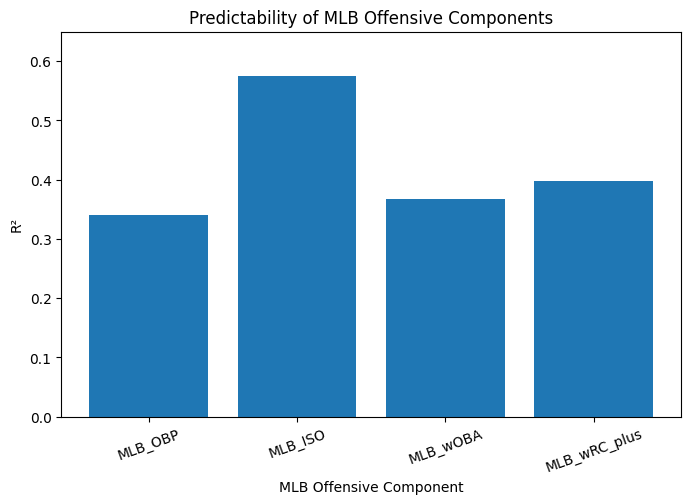

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    component_results["Target"],
    component_results["R²"]
)

plt.ylabel("R²")
plt.xlabel("MLB Offensive Component")
plt.title("Predictability of MLB Offensive Components")

plt.ylim(0, 0.65)
plt.xticks(rotation=20)

plt.show()

### Finding

MLB ISO was the most predictable offensive component, with an R² of 0.5753. The models predicting wRC+, wOBA, and OBP achieved lower R² values of 0.3971, 0.3673, and 0.3396, respectively.

This suggests that Minor League performance provides a stronger signal for future MLB power than for other aspects of offensive production. Power may be more transferable across levels of competition, while statistics such as OBP and overall offensive value are more sensitive to differences in competition quality and other factors that are not captured in the dataset.

This difference in predictability is also reflected in the construction of HAS, where multiple offensive components are combined rather than relying on a single statistic.

## Question 2: What Minor League Characteristics Does ProspectML Rely On Most?

Feature importance from the four component models is used to identify which Minor League statistics contribute most strongly to the model's predictions.

Feature importance does not indicate causation. Instead, it shows which variables the Extra Trees models relied on most when making predictions.

The analysis focuses on both individual features and broader categories of features, such as career statistics, AAA performance, AA performance, High-A performance, and age.

In [23]:
component_importance_final = {}

for target in component_targets:

    model = component_models[target]

    importance = pd.DataFrame({
        "Feature": final_features,
        "Importance": model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    component_importance_final[target] = importance

    print(f"\n===== {target} =====")
    print(importance.head(15))


===== MLB_OBP =====
            Feature  Importance
14       Career_OBP    0.222435
18  Career_wRC_plus    0.073616
17      Career_wOBA    0.052738
11      Career_BB/K    0.048200
9        Career_AVG    0.044702
10       Career_BB%    0.038035
15       Career_OPS    0.033595
2            AAA_K%    0.031439
0           AAA_BB%    0.027027
12       Career_ISO    0.026912
26   Career_Age_Max    0.025446
7             AA_K%    0.025090
13        Career_K%    0.024427
19        HighA_BB%    0.024099
25   Career_Age_Min    0.022978

===== MLB_ISO =====
            Feature  Importance
12       Career_ISO    0.344976
16       Career_SLG    0.134961
1           AAA_ISO    0.065897
18  Career_wRC_plus    0.042151
15       Career_OPS    0.034079
6            AA_ISO    0.032523
13        Career_K%    0.028917
25   Career_Age_Min    0.026090
26   Career_Age_Max    0.025590
20        HighA_ISO    0.024882
17      Career_wOBA    0.022454
32      AAA_Age_Max    0.018520
9        Career_AVG    0.01592

In [24]:
importance_summary = pd.DataFrame({
    target: component_importance_final[target]
        .set_index("Feature")["Importance"]
    for target in component_targets
})

importance_summary = importance_summary.fillna(0)

importance_summary["Average_Importance"] = (
    importance_summary.mean(axis=1)
)

importance_summary["Targets_Top_15"] = (
    importance_summary.index.to_series()
    .apply(
        lambda feature: sum(
            feature in component_importance_final[target]
                .head(15)["Feature"].values
            for target in component_targets
        )
    )
)

importance_summary = importance_summary.sort_values(
    "Average_Importance",
    ascending=False
)

importance_summary.head(20)

,MLB_OBP,MLB_ISO,MLB_wOBA,MLB_wRC_plus,Average_Importance,Targets_Top_15
Feature,,,,,,
Career_wRC_plus,0.073616,0.042151,0.200113,0.355523,0.167851,4
Career_ISO,0.026912,0.344976,0.027468,0.018572,0.104482,4
Career_wOBA,0.052738,0.022454,0.141730,0.155471,0.093098,4
Career_OPS,0.033595,0.034079,0.120570,0.119478,0.076930,4
Career_OBP,0.222435,0.013188,0.035628,0.029129,0.075095,3
Career_SLG,0.022779,0.134961,0.058775,0.048701,0.066304,3
AAA_ISO,0.018281,0.065897,0.015966,0.008176,0.027080,1
Career_Age_Max,0.025446,0.025590,0.027436,0.028447,0.026730,4
Career_Age_Min,0.022978,0.026090,0.020759,0.025887,0.023929,4


In [25]:
def feature_group(feature):

    if feature.startswith("Career_"):
        return "Career"

    elif feature.startswith("AAA_"):
        return "AAA"

    elif feature.startswith("AA_"):
        return "AA"

    elif feature.startswith("HighA_"):
        return "High-A"

    elif feature.startswith("Has_"):
        return "Level Experience"

    else:
        return "Other"


importance_summary["Group"] = (
    importance_summary.index.map(feature_group)
)

In [31]:
group_importance = (
    importance_summary
    .groupby("Group")["Average_Importance"]
    .sum()
    .sort_values(ascending=False)
)

group_importance

Group
Career              0.716874
AAA                 0.128714
AA                  0.081642
High-A              0.072769
Level Experience    0.000000
Name: Average_Importance, dtype: float64

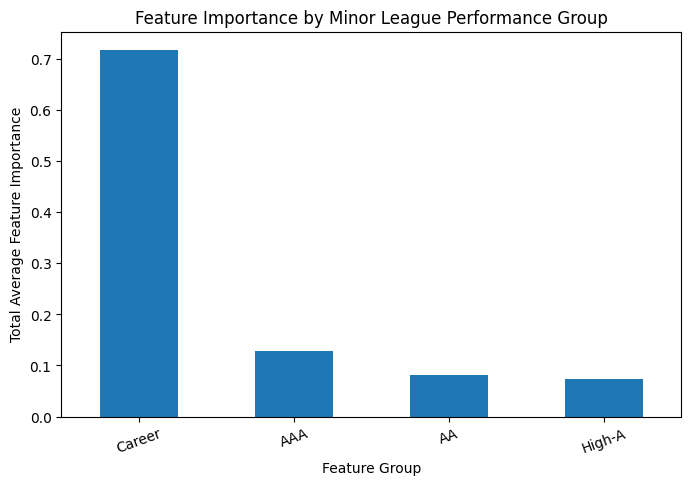

In [66]:
plt.figure(figsize=(8, 5))

group_importance.drop("Level Experience").plot(
    kind="bar"
)

plt.ylabel("Total Average Feature Importance")
plt.xlabel("Feature Group")
plt.title("Feature Importance by Minor League Performance Group")

plt.xticks(rotation=20)

plt.show()

In [33]:
top_features = importance_summary.head(15)

top_features[[
    "Average_Importance",
    "Targets_Top_15"
]]

,Average_Importance,Targets_Top_15
Feature,,
Career_wRC_plus,0.167851,4
Career_ISO,0.104482,4
Career_wOBA,0.093098,4
Career_OPS,0.076930,4
Career_OBP,0.075095,3
Career_SLG,0.066304,3
AAA_ISO,0.027080,1
Career_Age_Max,0.026730,4
Career_Age_Min,0.023929,4


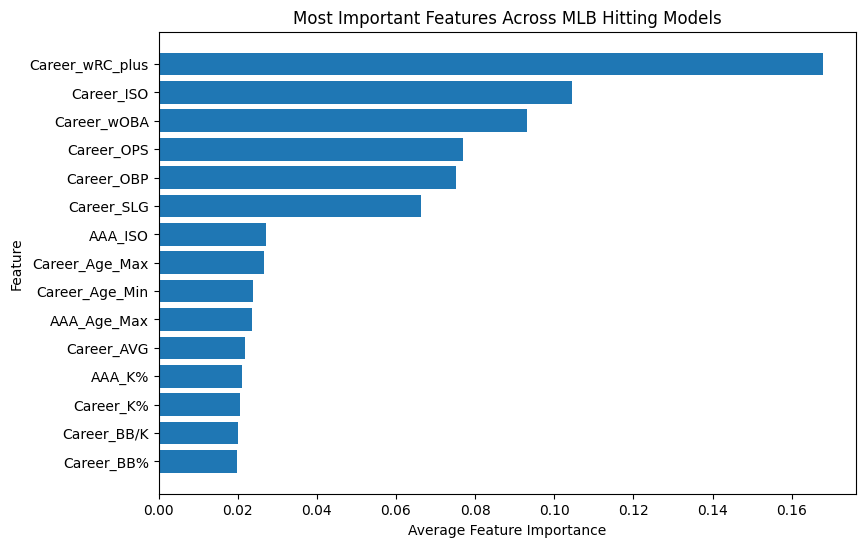

In [29]:
top_features = (
    importance_summary
    .head(15)
    .sort_values("Average_Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features.index,
    top_features["Average_Importance"]
)

plt.xlabel("Average Feature Importance")
plt.ylabel("Feature")
plt.title("Most Important Features Across MLB Hitting Models")

plt.show()

### Finding

The feature-importance analysis shows that ProspectML relies heavily on career-level Minor League statistics when predicting future MLB hitting performance.

Career-level features accounted for approximately 71.7% of the total average feature importance across the four component models. AAA, AA, and High-A features accounted for approximately 12.9%, 8.2%, and 7.3%, respectively.

The most consistently important individual features were Career_wRC_plus, Career_ISO, Career_wOBA, and Career_OPS. Each appeared among the 15 most important features in all four component models. Career_OBP and Career_SLG were also consistently important, appearing in the top 15 for three of the four models.

These results suggest that a player's overall Minor League track record provides a stronger and more consistent predictive signal than performance at any individual level. This makes intuitive sense because career statistics incorporate performance across multiple seasons and levels of competition and are generally less affected by the variation present in a single-season sample.

However, the importance of career statistics should not be interpreted as proof that career performance is inherently more important than individual-level performance. Career statistics contain more accumulated information and are therefore likely to be more stable. In addition, many of the career offensive statistics are highly correlated with one another, meaning that feature importance can be distributed across several variables measuring similar aspects of hitting ability.

The results therefore support the broader conclusion that ProspectML relies primarily on a player's established Minor League offensive profile, particularly measures of overall offensive production and power, rather than identifying one individual statistic as the single most important predictor.

### Interpretation

An important distinction is that feature importance measures what the model uses to make predictions, not what causes MLB success.

The dominance of career-level statistics may partly reflect their larger and more stable samples, while the strong presence of power-related statistics may reflect the fact that MLB ISO was the most predictable of the four modeled offensive components. These factors should be considered when interpreting the model's feature-importance results.

## Question 3: Does Minor League Level Matter?

Minor League hitters can accumulate statistics across High-A, AA, and AAA. One potential question for prospect evaluation is whether performance at higher levels provides more information about future MLB hitting ability.

The feature-importance results from Question 2 suggest that AAA statistics contribute more to the model than AA or High-A statistics. However, feature importance alone does not establish that performance at one level is more predictive than another.

This section therefore examines both the model's reliance on each level and the relationship between level-specific Minor League statistics and future MLB hitting outcomes.

In [42]:
level_importance = pd.Series({
    "High-A": group_importance["High-A"],
    "AA": group_importance["AA"],
    "AAA": group_importance["AAA"]
}).sort_values(ascending=False)

level_importance

AAA       0.128714
AA        0.081642
High-A    0.072769
dtype: float64

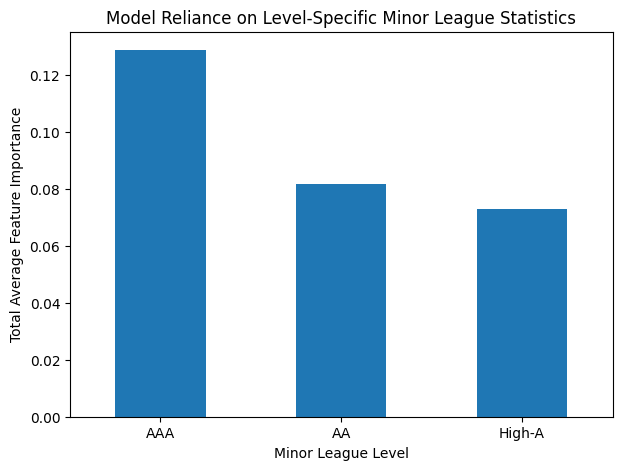

In [35]:
plt.figure(figsize=(7, 5))

level_importance.plot(kind="bar")

plt.ylabel("Total Average Feature Importance")
plt.xlabel("Minor League Level")
plt.title("Model Reliance on Level-Specific Minor League Statistics")

plt.xticks(rotation=0)

plt.show()

In [36]:
level_features = [
    col for col in final_features
    if col.startswith(("HighA_", "AA_", "AAA_"))
]

mlb_targets = [
    "MLB_OBP",
    "MLB_ISO",
    "MLB_wOBA",
    "MLB_wRC_plus"
]

level_correlations = []

for feature in level_features:

    for target in mlb_targets:

        corr = prospectml_model[feature].corr(
            prospectml_model[target]
        )

        level_correlations.append({
            "Feature": feature,
            "Target": target,
            "Correlation": corr
        })

level_correlations = pd.DataFrame(level_correlations)

level_correlations.head()

,Feature,Target,Correlation
0,AAA_BB%,MLB_OBP,0.234455
1,AAA_BB%,MLB_ISO,0.108810
2,AAA_BB%,MLB_wOBA,0.146567
3,AAA_BB%,MLB_wRC_plus,0.139981
4,AAA_ISO,MLB_OBP,-0.001538


In [43]:
level_correlations["Level"] = (
    level_correlations["Feature"]
    .str.extract(r"^(HighA|AA|AAA)_")[0]
)

level_correlations["Abs_Correlation"] = (
    level_correlations["Correlation"].abs()
)

strongest_by_level = (
    level_correlations
    .sort_values(
        ["Level", "Abs_Correlation"],
        ascending=[True, False]
    )
)

print(strongest_by_level.groupby("Level").head(10))

        Feature        Target  Correlation  Level  Abs_Correlation
25       AA_ISO       MLB_ISO     0.432747     AA         0.432747
27       AA_ISO  MLB_wRC_plus     0.298333     AA         0.298333
29        AA_K%       MLB_ISO     0.293710     AA         0.293710
33       AA_SLG       MLB_ISO     0.286248     AA         0.286248
26       AA_ISO      MLB_wOBA     0.266821     AA         0.266821
35       AA_SLG  MLB_wRC_plus     0.243776     AA         0.243776
34       AA_SLG      MLB_wOBA     0.208955     AA         0.208955
20       AA_BB%       MLB_OBP     0.188472     AA         0.188472
23       AA_BB%  MLB_wRC_plus     0.163720     AA         0.163720
21       AA_BB%       MLB_ISO     0.129250     AA         0.129250
5       AAA_ISO       MLB_ISO     0.442985    AAA         0.442985
9        AAA_K%       MLB_ISO     0.284810    AAA         0.284810
17      AAA_SLG       MLB_ISO     0.267935    AAA         0.267935
0       AAA_BB%       MLB_OBP     0.234455    AAA         0.23

In [38]:
average_level_correlation = (
    level_correlations
    .groupby("Level")["Abs_Correlation"]
    .mean()
    .sort_values(ascending=False)
)

average_level_correlation

Level
AAA      0.137622
AA       0.135608
HighA    0.106392
Name: Abs_Correlation, dtype: float64

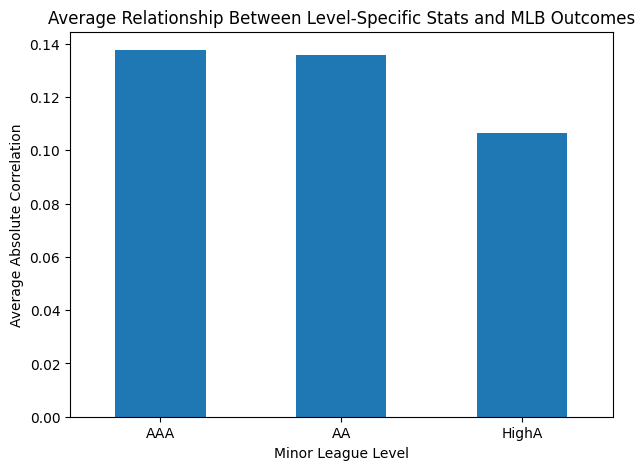

In [39]:
plt.figure(figsize=(7, 5))

average_level_correlation.plot(kind="bar")

plt.ylabel("Average Absolute Correlation")
plt.xlabel("Minor League Level")
plt.title("Average Relationship Between Level-Specific Stats and MLB Outcomes")

plt.xticks(rotation=0)

plt.show()

In [49]:
sample_sizes = {}

for level in ["HighA", "AA", "AAA"]:
    
    age_min_col = f"{level}_Age_Min"
    
    sample_sizes[level] = (
        prospectml_model[age_min_col] > 0
    ).sum()

pd.Series(sample_sizes)

HighA    810
AA       854
AAA      892
dtype: int64

### Sample Size Consideration

The number of players with recorded experience at each Minor League level differs slightly across the dataset. High-A includes 810 players, AA includes 854 players, and AAA includes 892 players out of 936 total players.

Because the sample sizes are not identical, differences in correlations and feature importance between levels should be interpreted cautiously. In particular, the greater representation of AAA players does not by itself mean that AAA performance is more predictive.

The level-specific results are therefore interpreted alongside the model's feature importance and correlation analysis rather than as evidence that one Minor League level is universally more predictive than another.

### Finding

AAA statistics provided the greatest overall contribution among the three individual Minor League levels, accounting for 12.9% of average feature importance compared with 8.2% for AA and 7.3% for High-A.

The correlation analysis showed a similar pattern, although the difference between AAA and AA was very small. AAA-level features had an average absolute correlation of 0.1376 with the four MLB outcomes, compared with 0.1356 for AA and 0.1064 for High-A.

These results suggest that performance at the higher Minor League levels generally provides more information about future MLB hitting than High-A performance. However, the difference between AAA and AA was minimal, so the results do not support a strong claim that AAA is substantially more predictive than AA.

The strongest individual level-specific relationship was between AA ISO and MLB ISO, with a correlation of 0.433. This reinforces the finding from Question 1 that power is one of the more transferable aspects of hitting ability.

Overall, the results suggest that higher-level Minor League performance contains useful information about future MLB hitting, but the player's broader career performance remains substantially more important to the finalized model than any single Minor League level.

## Question 4: Where Does ProspectML Succeed and Fail?

A model's overall performance can hide important differences between individual players.

To better understand ProspectML's strengths and limitations, prediction errors are examined at the player level. Players with the largest positive errors represent cases where the model underestimated actual MLB performance, while large negative errors represent cases where the model overestimated actual MLB performance.

Examining these extreme cases can help identify situations where Minor League statistics alone may not fully capture future MLB performance.

In [50]:
largest_overpredictions = (
    has_analysis
    .sort_values("Prediction_Error", ascending=False)
    .head(15)
)

largest_underpredictions = (
    has_analysis
    .sort_values("Prediction_Error", ascending=True)
    .head(15)
)

print("===== LARGEST OVERPREDICTIONS =====")
print(largest_overpredictions)

print("\n===== LARGEST UNDERPREDICTIONS =====")
print(largest_underpredictions)

===== LARGEST OVERPREDICTIONS =====
             PlayerID  HAS_weighted  Predicted_HAS  Prediction_Error
252         isan_diaz     -2.159012      -0.030759          2.128253
249      brandon_wood     -2.713803      -0.615177          2.098626
429    cristian_pache     -2.405006      -0.337449          2.067558
886       ji_hwan_bae     -1.461076       0.379910          1.840986
633    carter_kieboom     -1.248247       0.592325          1.840572
387      vidal_brujan     -2.014199      -0.209172          1.805027
180     lewis_brinson     -1.891157      -0.176359          1.714798
75      taylor_motter     -2.010382      -0.447805          1.562577
302     michael_perez     -1.978817      -0.448715          1.530103
49       carlos_perez     -1.559877      -0.043236          1.516641
788     oswald_peraza     -1.990997      -0.494222          1.496775
629     austin_hedges     -2.075026      -0.591681          1.483345
131  andrew_velazquez     -2.233242      -0.759613          1.47362

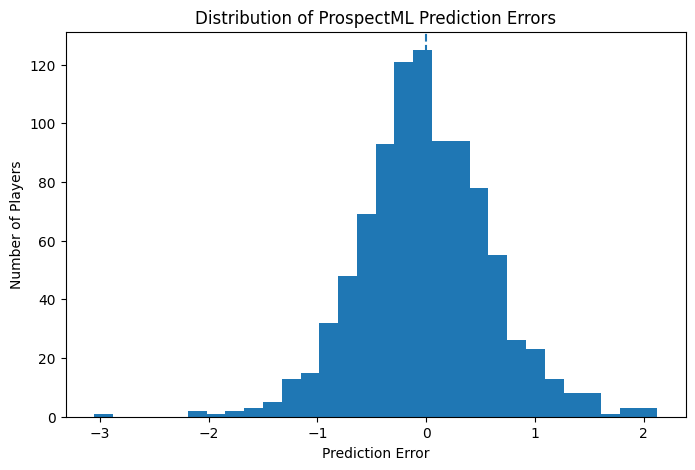

In [51]:
plt.figure(figsize=(8, 5))

plt.hist(
    has_analysis["Prediction_Error"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error")
plt.ylabel("Number of Players")
plt.title("Distribution of ProspectML Prediction Errors")

plt.show()

### Prediction Error Distribution

The distribution of prediction errors shows how closely ProspectML's predictions generally align with actual MLB-based Hitter Ability Scores.

Errors near zero represent players whose MLB performance was close to the model's prediction. Larger positive or negative errors represent players whose actual MLB performance differed substantially from the model's expectation.

The distribution also illustrates the model's tendency to predict toward the center of the HAS distribution, which makes extreme outcomes more difficult to predict accurately.

In [59]:
top_actual_has = (
    has_analysis[
        [
            "PlayerID",
            "HAS_weighted",
            "Predicted_HAS",
            "Prediction_Error"
        ]
    ]
    .sort_values(
        "HAS_weighted",
        ascending=False
    )
    .head(15)
)

top_actual_has

,PlayerID,HAS_weighted,Predicted_HAS,Prediction_Error
674,aaron_judge,4.336187,1.278742,-3.057444
743,mike_trout,3.720085,1.697112,-2.022973
835,yordan_alvarez,3.460363,1.701891,-1.758472
782,joey_votto,2.938699,1.370418,-1.568281
822,ronald_acuna_jr,2.712035,0.749906,-1.962128
566,freddie_freeman,2.539504,0.953172,-1.586332
723,paul_goldschmidt,2.357349,1.650725,-0.706624
746,mookie_betts,2.293432,1.288177,-1.005256
698,giancarlo_stanton,2.251385,1.366899,-0.884486
368,kyle_tucker,2.202557,1.088331,-1.114226


In [58]:
bottom_actual_has = (
    has_analysis[
        [
            "PlayerID",
            "HAS_weighted",
            "Predicted_HAS",
            "Prediction_Error"
        ]
    ]
    .sort_values(
        "HAS_weighted",
        ascending=True
    )
    .head(15)
)

bottom_actual_has

,PlayerID,HAS_weighted,Predicted_HAS,Prediction_Error
42,michael_martinez,-2.807268,-1.344957,1.462311
249,brandon_wood,-2.713803,-0.615177,2.098626
429,cristian_pache,-2.405006,-0.337449,2.067558
758,koyie_hill,-2.390867,-1.440096,0.950770
179,magneuris_sierra,-2.254996,-0.962339,1.292656
432,drew_butera,-2.236840,-1.091437,1.145403
131,andrew_velazquez,-2.233242,-0.759613,1.473628
917,jeff_mathis,-2.182757,-1.196191,0.986566
252,isan_diaz,-2.159012,-0.030759,2.128253
730,nick_allen,-2.145140,-1.008608,1.136532


In [60]:
extreme_analysis = pd.DataFrame({
    "Actual_HAS": has_analysis["HAS_weighted"],
    "Predicted_HAS": has_analysis["Predicted_HAS"]
})

extreme_analysis["Actual_Absolute"] = (
    extreme_analysis["Actual_HAS"].abs()
)

extreme_analysis["Predicted_Absolute"] = (
    extreme_analysis["Predicted_HAS"].abs()
)

print(
    "Average absolute actual HAS:",
    extreme_analysis["Actual_Absolute"].mean()
)

print(
    "Average absolute predicted HAS:",
    extreme_analysis["Predicted_Absolute"].mean()
)

Average absolute actual HAS: 0.7347072450502551
Average absolute predicted HAS: 0.4634536903164752


In [61]:
high_actual = (
    has_analysis["HAS_weighted"]
    .abs() >= 2
)

print(
    "Players with |Actual HAS| >= 2:",
    high_actual.sum()
)

print(
    "Average absolute error for these players:",
    has_analysis.loc[
        high_actual,
        "Prediction_Error"
    ].abs().mean()
)

print(
    "Overall average absolute error:",
    has_analysis["Prediction_Error"].abs().mean()
)

Players with |Actual HAS| >= 2: 32
Average absolute error for these players: 1.3914054789162025
Overall average absolute error: 0.46373227693053554


### Finding

The largest prediction errors reveal an important limitation of ProspectML: the model struggles most with extreme MLB outcomes.

The largest underpredictions were concentrated among some of the most successful hitters in the dataset. Aaron Judge had the highest actual HAS at 4.34 but a predicted HAS of only 1.28, producing an error of -3.06. Other notable underpredictions included Mike Trout (-2.02), Ronald Acuña Jr. (-1.96), Yordan Alvarez (-1.76), Freddie Freeman (-1.59), and Joey Votto (-1.57).

The model also made substantial overpredictions among players who ultimately produced relatively poor MLB hitting results. Isan Díaz had an actual HAS of -2.16 but a predicted HAS near zero, producing the largest positive error of 2.13. Brandon Wood and Cristian Pache produced similarly large overpredictions.

The overall distribution of predictions provides additional evidence of this limitation. The average absolute actual HAS was 0.735, compared with only 0.463 for predicted HAS. This indicates that the model's predictions are substantially more concentrated around the center of the distribution than the actual outcomes.

The effect becomes particularly clear among extreme outcomes. There were 32 players with an absolute actual HAS of at least 2. For these players, the average absolute prediction error was 1.391, compared with an overall average absolute error of only 0.464. In other words, extreme outcomes were associated with roughly three times the typical prediction error.

This suggests that ProspectML is more effective at estimating a player's general offensive ability than identifying extreme outcomes, particularly future stars. The model appears to regress extreme players toward the average, making it difficult to identify players who will substantially outperform or underperform their statistical expectations.

This is an important limitation for prospect evaluation. Some of the most valuable outcomes are players who substantially exceed expectations, and these players may possess characteristics that are not captured by the Minor League statistics included in the model. ProspectML should therefore be viewed as a tool for identifying and comparing broad offensive profiles rather than as a definitive ranking system or replacement for scouting.

## Question 5: What Can ProspectML Actually Tell Us?

The final question is broader than model performance. The purpose of ProspectML was not simply to maximize predictive accuracy, but to investigate what Minor League statistics can tell us about future MLB hitting performance.

The previous analyses showed that some aspects of MLB hitting are more predictable than others, that career Minor League performance provides the strongest overall signal, that performance at higher levels provides additional information, and that extreme MLB outcomes remain difficult to predict.

Together, these findings help define the appropriate role for ProspectML in a real baseball analytics environment.

In [62]:
baseline_results = pd.DataFrame({
    "Model": ["Baseline", "Final ProspectML"],
    "MAE": [0.7743, 0.5719],
    "RMSE": [0.9348, 0.7186],
    "R²": [-0.0107, 0.4027]
})

baseline_results

,Model,MAE,RMSE,R²
0,Baseline,0.7743,0.9348,-0.0107
1,Final ProspectML,0.5719,0.7186,0.4027


### ProspectML vs. Baseline

The finalized ProspectML model substantially outperformed a simple baseline prediction.

The baseline model produced an R² of approximately -0.011, meaning that it provided essentially no improvement over predicting the average HAS for every player. ProspectML increased R² to 0.403 while reducing both MAE and RMSE.

This demonstrates that the Minor League information used by ProspectML contains meaningful predictive signal for future MLB hitting performance.

In [63]:
mae_improvement = (0.7743 - 0.5719) / 0.7743
rmse_improvement = (0.9348 - 0.7186) / 0.9348

print(f"MAE improvement: {mae_improvement:.1%}")
print(f"RMSE improvement: {rmse_improvement:.1%}")

MAE improvement: 26.1%
RMSE improvement: 23.1%


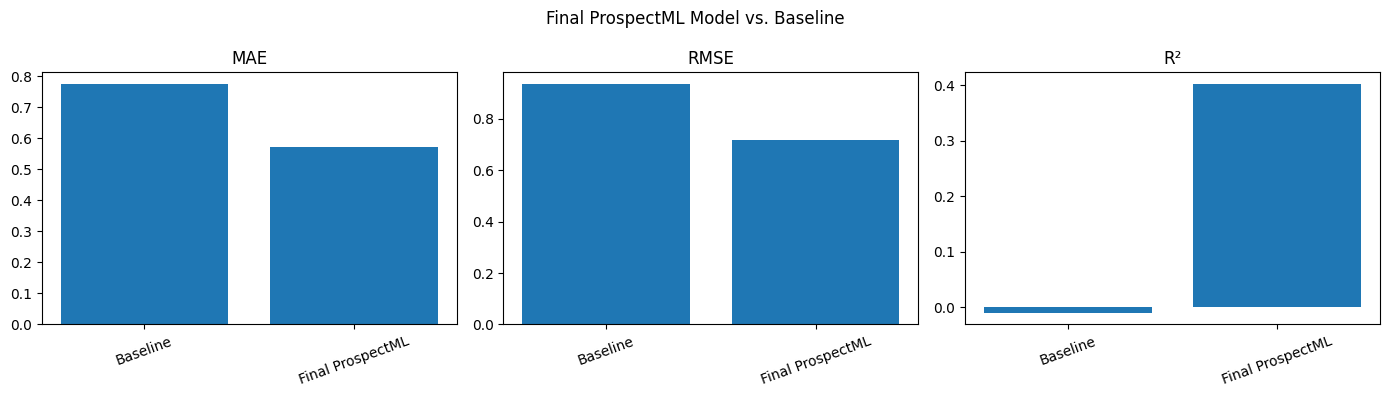

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ["MAE", "RMSE", "R²"]

for i, metric in enumerate(metrics):

    axes[i].bar(
        baseline_results["Model"],
        baseline_results[metric]
    )

    axes[i].set_title(metric)
    axes[i].tick_params(axis="x", rotation=20)

plt.suptitle("Final ProspectML Model vs. Baseline")

plt.tight_layout()
plt.show()

## Final Conclusion

ProspectML demonstrates that Minor League hitting statistics contain meaningful information about future MLB offensive performance, but that information has clear limits.

The finalized model achieved an R² of 0.403 with an MAE of 0.572, substantially outperforming the baseline model. This indicates that Minor League performance can be used to estimate future MLB hitting ability better than simply assuming every player will perform at the population average.

However, the results also show that MLB hitting is only partially predictable from the variables included in this dataset. MLB ISO was the most predictable component, while OBP, wOBA, and wRC+ were more difficult to project. The model relied heavily on career Minor League statistics, suggesting that a player's established offensive track record provides a stronger signal than performance from any single Minor League level.

Performance at higher Minor League levels also provided useful information. AAA statistics contributed more to the model than AA or High-A statistics, although the difference between AAA and AA was relatively small. This suggests that level of competition matters, but that a player's broader career record remains more important than any individual level.

The largest limitation of ProspectML was its difficulty predicting extreme outcomes. Players with an absolute actual HAS of at least 2 had an average absolute prediction error of 1.39, approximately three times the overall error of 0.46. This was especially evident among elite MLB hitters such as Aaron Judge and Mike Trout, whose eventual performance substantially exceeded the model's predictions.

These results suggest that ProspectML should not be viewed as a definitive prospect ranking system. Instead, its greatest value may be as a decision-support tool. The model can provide a consistent statistical baseline, identify prospects with strong or unusual Minor League profiles, compare players across a common framework, and generate questions for further scouting and analysis.

The project also demonstrates an important principle of baseball analytics: predictive models do not need to perfectly predict the future to provide useful information. A model can identify meaningful patterns while still leaving substantial uncertainty around individual players. In a real baseball organization, ProspectML would therefore be most useful when combined with scouting information, physical characteristics, underlying performance data, and other information not captured in the current dataset.

## Future Improvements

Although ProspectML provides meaningful predictive information, several improvements could make the model more accurate and more useful in a real baseball environment.

### 1. Add More Player-Level Data

The current model relies primarily on traditional Minor League statistics. Adding additional information could capture aspects of player development that statistics alone miss.

Potential additions include:

- Exit velocity and batted-ball data
- Launch angle
- Barrel rate
- Hard-hit rate
- Plate discipline and chase rate
- Contact quality
- Sprint speed
- Defensive position and versatility
- Physical measurements
- Age relative to league
- Injury history

These variables could help explain why some players outperform or underperform their statistical expectations.

### 2. Better Account for Level of Competition

The current model includes statistics from High-A, AA, and AAA, but does not fully adjust for the difficulty of competition.

A future version could incorporate league- or level-adjusted statistics, allowing the model to distinguish between similar performances achieved against different levels of competition.

This could be particularly useful when comparing players who have accumulated similar statistics at different stages of their development.

### 3. Incorporate Year-to-Year Development

The current model focuses heavily on career statistics. Career statistics provide a large and stable sample, but they can also hide changes in a player's performance over time.

Future versions could incorporate trends such as:

- Improvement or decline in wRC+
- Changes in ISO
- Changes in BB% and K%
- Recent-season performance
- Rate of improvement between levels

This could allow the model to distinguish between a player who is consistently good and a player who is rapidly improving.

### 4. Improve the Target Variable

HAS_weighted is useful as a summary measure, but it is ultimately a constructed target based on four MLB offensive outcomes.

Future versions could explore alternative targets, such as:

- MLB WAR
- MLB wRC+
- MLB OPS+
- Probability of reaching an MLB performance threshold
- Probability of becoming an above-average MLB hitter

Different targets could answer different baseball questions and may be easier to interpret for coaches, scouts, and front-office personnel.

### 5. Test Additional Modeling Approaches

The finalized Random Forest performed well, but future versions could compare it with additional methods, including:

- Gradient boosting
- XGBoost
- LightGBM
- Regularized linear regression
- Elastic Net
- Neural networks

Different models may capture different relationships between Minor League performance and MLB outcomes.

### 6. Increase the Dataset

The current dataset contains 936 players. Expanding the dataset to include more players and additional seasons could improve the stability of the model and make it easier to evaluate how well the model generalizes to new players.

A larger dataset would also make it possible to test the model separately across different eras, positions, and player types.

### 7. Add Scouting and Tracking Information

The largest prediction errors suggest that statistical Minor League performance does not capture everything that determines MLB success.

A future organizational version of ProspectML could combine statistical projections with information such as scouting grades, TrackMan/Statcast data, HitTrax measurements, physical development, and injury information.

This would move the project closer to a true decision-support system rather than a purely statistical projection model.

ProspectML should therefore be viewed as a foundation rather than a finished projection system. The current model demonstrates that meaningful predictive signal exists in Minor League statistics, while the model's limitations identify clear opportunities for future development. Adding tracking data, competition adjustments, player-development trends, and scouting information could potentially improve both predictive accuracy and practical usefulness.

In [65]:
final_findings = pd.DataFrame({
    "Question": [
        "Most predictable MLB skill",
        "Most important information source",
        "Most informative Minor League level",
        "Biggest model limitation",
        "Final model R²"
    ],
    
    "Finding": [
        "MLB ISO / power",
        "Career Minor League performance",
        "AAA, although AA was very similar",
        "Extreme MLB outcomes",
        "0.4027"
    ]
})

final_findings

,Question,Finding
0,Most predictable MLB skill,MLB ISO / power
1,Most important information source,Career Minor League performance
2,Most informative Minor League level,"AAA, although AA was very similar"
3,Biggest model limitation,Extreme MLB outcomes
4,Final model R²,0.4027
